In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "../output_videos/cropped_image.jpg" 
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

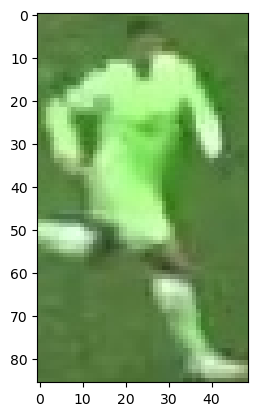

In [4]:
plt.imshow(image)
plt.show()

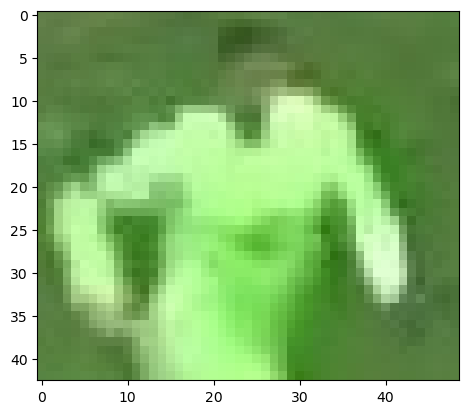

In [5]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters

In [11]:
# Reshape the image into a 2d array
image_2d = top_half_image.reshape(-1,3)

# perform k-means clustering into 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

print(kmeans)

# get the cluster labels
labels = kmeans.labels_

# reshape the label into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])



KMeans(n_clusters=2, random_state=0)


# Get average colour of each cluster pixels

In [7]:
# first get the labels at each of the corners, eg (0,0) is top left, (0,-1) is top right (labels.reshape earlier has it as clustered_image[row, col])
# now get a set so that its {0,1} only since 2 clusters only
# whichever cluster shows up the most in the corners is most likely going to be the background cluster
# so this second line picks the cluster label (0,1) that appears the most in the corners

corner_clusters = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [8]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

0


In [9]:
# this prints out the rgb value of the average pixel in that cluster
kmeans.cluster_centers_[player_cluster]

array([170.49668874, 235.87549669, 142.25827815])